<a href="https://colab.research.google.com/github/refimaulan06/Covid-19-Analysis/blob/main/Covid_19_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as mtp
import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn import preprocessing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
copid = pd.read_csv('/content/copid.csv')

In [ ]:
copid.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [ ]:
copid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [ ]:
copid.shape

(187, 15)

In [ ]:
copid.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,187.000000,187.000000,187.000000,187.000000,187.00000,187.000000,187.000000,187.000000,187.000000,187.00,187.000000,187.000000,187.000000
mean,43883.780749,1744.208556,29332.443850,13194.748663,411.42246,10.144385,329.288770,3.019519,64.820535,inf,40662.844920,2912.165775,13.606203
std,81764.215845,3977.697522,62404.530722,26278.092381,749.48395,23.897305,685.222177,3.454302,26.287694,NaN,76884.498993,5080.798764,24.509838
min,27.000000,0.000000,13.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00,24.000000,0.000000,-3.840000
25%,1114.000000,18.500000,626.500000,141.500000,4.00000,0.000000,0.000000,0.945000,48.770000,1.45,1051.500000,49.000000,2.775000
50%,5059.000000,108.000000,2815.000000,1600.000000,49.00000,1.000000,22.000000,2.150000,71.320000,3.62,5020.000000,432.000000,6.890000
75%,40460.500000,734.000000,22606.000000,9149.000000,419.50000,6.000000,221.000000,3.875000,86.885000,6.44,37080.500000,3172.000000,16.855000
max,293606.000000,15912.000000,241026.000000,98752.000000,2772.00000,96.000000,2613.000000,28.560000,100.000000,inf,276202.000000,18772.000000,226.320000


# Correlation Matrix

In [ ]:
# Pilih kolom numerik untuk analisis korelasi
numerical_columns = copid.select_dtypes(include=['int64']).columns
numerical_data = copid[numerical_columns]

# Hitung matriks korelasi
correlation_matrix = numerical_data.corr()

# Korelasi variabel 'Confirmed' dengan variabel lainnya
correlation_with_actual_time = correlation_matrix['Confirmed'].sort_values(ascending=False)
print(correlation_with_actual_time)

Confirmed              1.000000
Confirmed last week    0.999127
1 week change          0.954710
Deaths                 0.934698
Active                 0.927018
New cases              0.909720
Recovered              0.906377
New deaths             0.871683
New recovered          0.859252
Name: Confirmed, dtype: float64


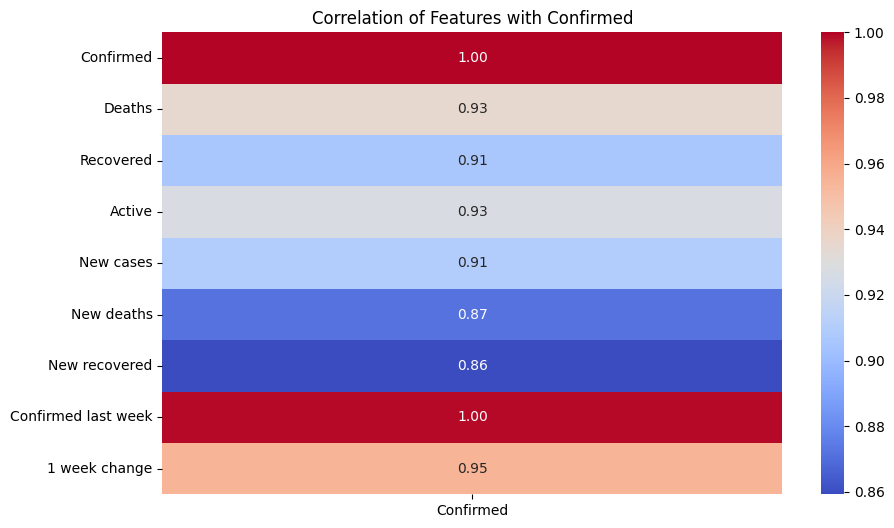

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix[['Confirmed']], annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation of Features with Confirmed')
plt.show()

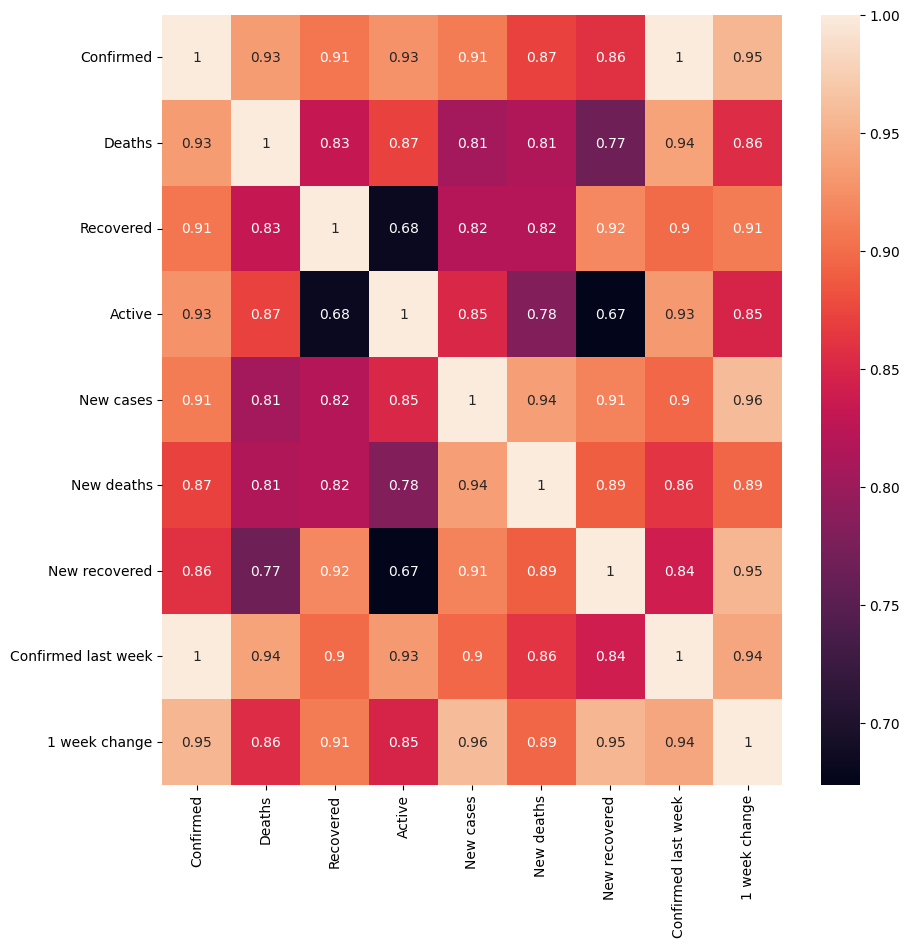

In [ ]:
numeric_cols = copid.select_dtypes(include=['int64']).columns
correlation_matrix = copid[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

# Linear Regression

In [ ]:
X = copid['Confirmed']

In [ ]:
X = copid['New cases']

In [ ]:
y = copid['Deaths']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=2529)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((130,), (57,), (130,), (57,))

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train.values.reshape(-1, 1),y_train)

LinearRegression()

In [ ]:
print(f"Koefisien: {model.coef_}")
print(f"Intersep: {model.intercept_}")

Koefisien: [2.46881282]
Intersep: 851.2453059769305


In [ ]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

In [ ]:
y_pred

array([   851.24530598,    851.24530598,    853.71411879,    853.71411879,
          851.24530598, 139934.28418748,    868.5269957 ,   1026.53101601,
         1999.24326607,    851.24530598,   1759.76842278,    851.24530598,
         2004.18089171,   1226.50485422,    868.5269957 ,  12923.7399831 ,
          868.5269957 ,   1683.23522544,    972.21713403,   1888.14668929,
          875.93343415,    851.24530598,   6117.22304551,   2655.9474755 ,
         1325.25736692,   1851.11449703,   1063.56320827,   1019.12457756,
          856.18293161, 110607.25672949,    853.71411879,    893.21512387,
          851.24530598,   2043.68189679,   2075.77646341,   1194.4102876 ,
          851.24530598,   1145.03403125,    851.24530598,   4618.65366534,
          873.46462133,   1083.31371081,    851.24530598,   1503.01188977,
         1120.34590307,   1251.1929824 ,   7149.18680318,   3576.8146564 ,
         1843.70805857,    858.65174443,   1140.09640561,    853.71411879,
         2525.10039618,  

In [ ]:
mean_absolute_error(y_test,y_pred)
mean_absolute_percentage_error(y_test,y_pred)
mean_squared_error(y_test,y_pred)

131873381.58158389

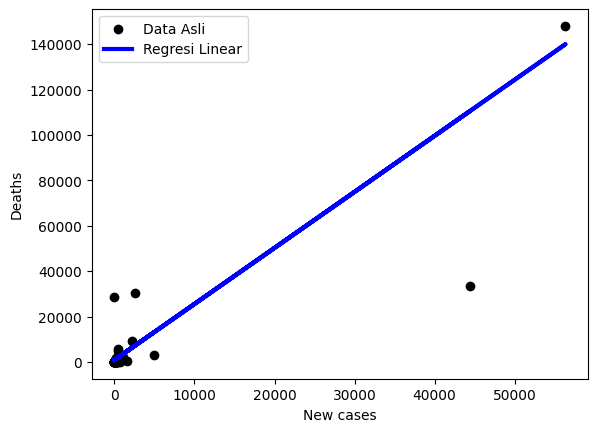

In [ ]:
plt.scatter(X_test, y_test, color='black', label='Data Asli')
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Regresi Linear')
plt.xlabel('Confirmed')
plt.xlabel('New cases')
plt.ylabel('Deaths')
plt.legend()
plt.show()

# Pengecekkan Outliers

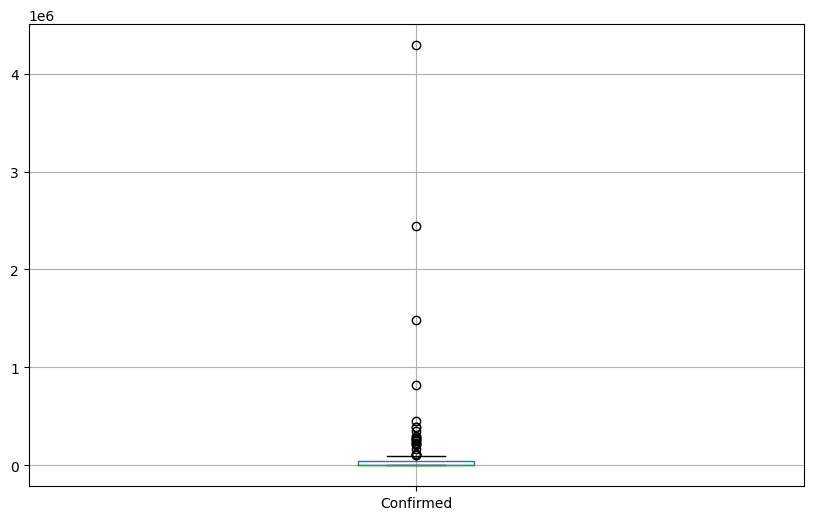

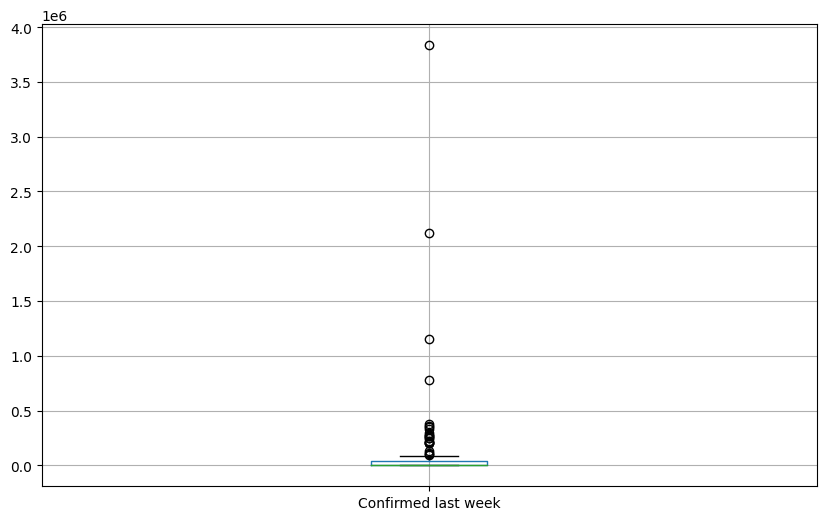

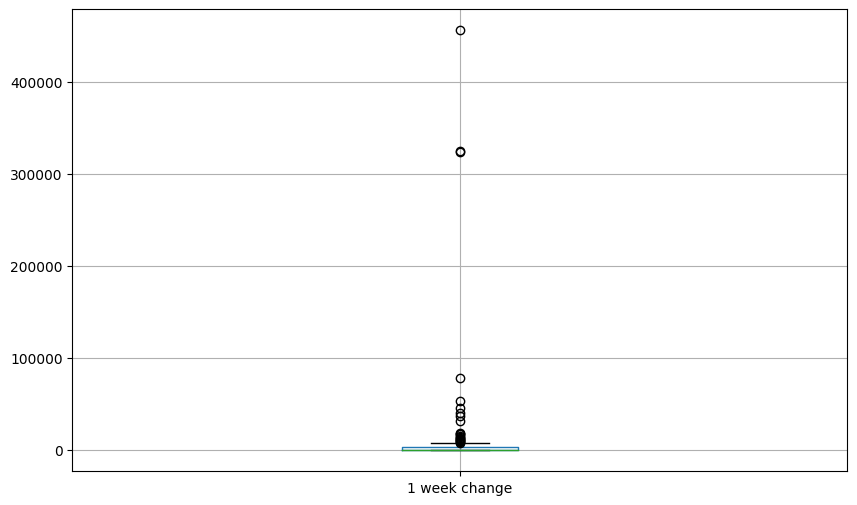

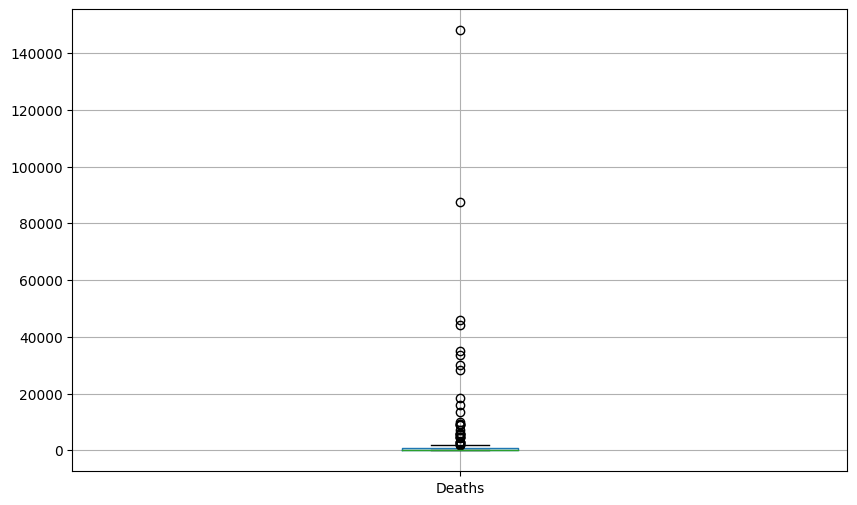

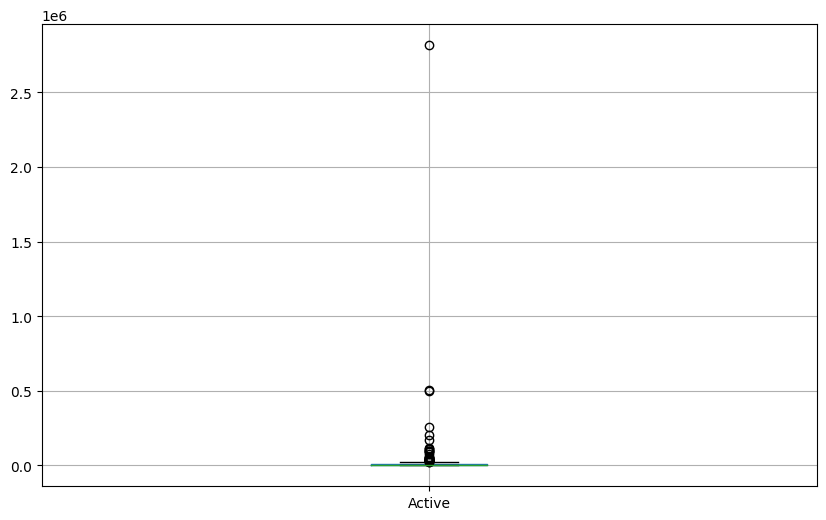

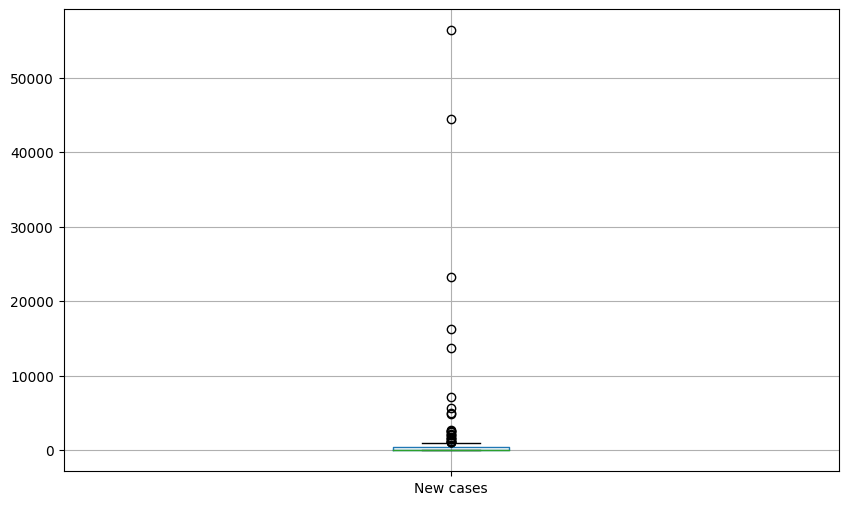

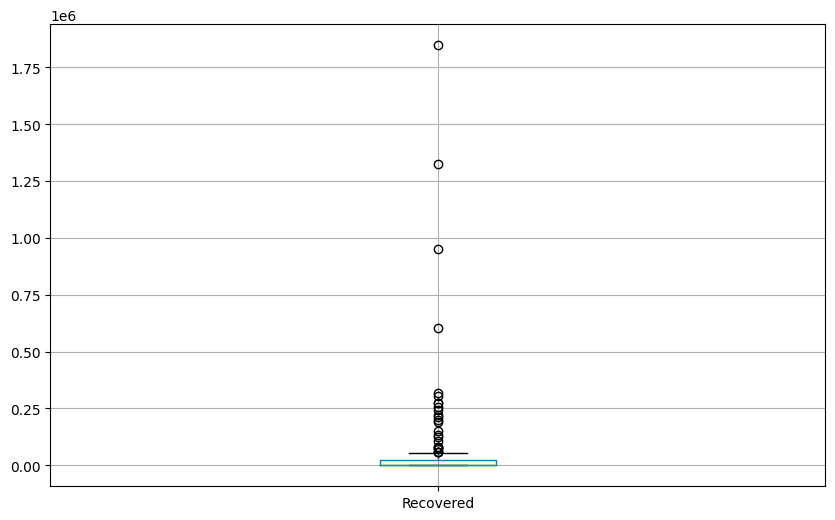

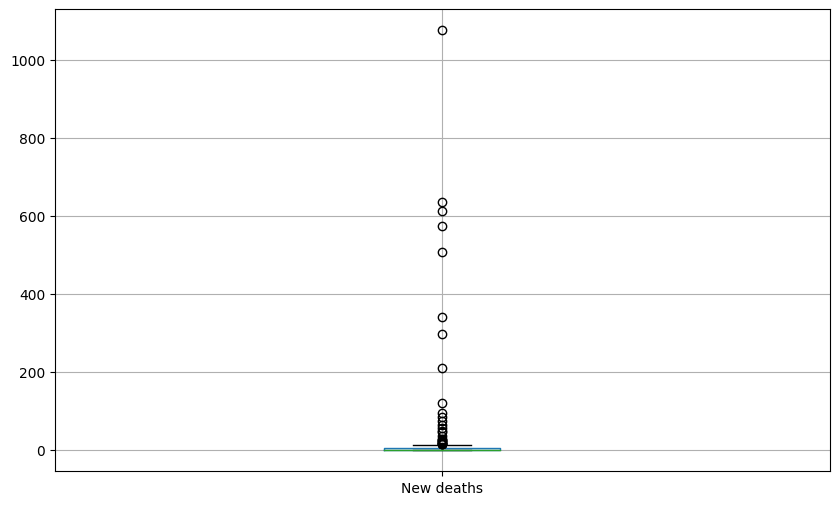

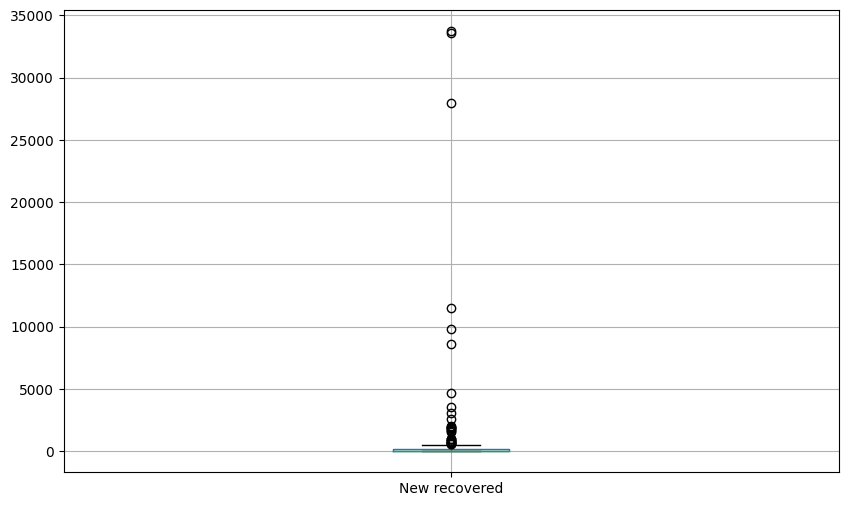

In [ ]:
numerik = ['Confirmed', 'Confirmed last week', '1 week change', 'Deaths', 'Active', 'New cases', 'Recovered',
  'New deaths', 'New recovered']

for i in copid[numerik]:
  plt.figure(figsize=(10,6))
  copid.boxplot(column=[i])

In [ ]:
from scipy.stats import mstats

# Winsorizing pada kolom-kolom tertentu
cols = ['Confirmed', 'Confirmed last week', '1 week change', 'Deaths', 'Active', 'New cases', 'Recovered', 'New deaths', 'New recovered']
copid[cols] = copid[cols].apply(lambda x: mstats.winsorize(x, limits=[0.05, 0.05]))

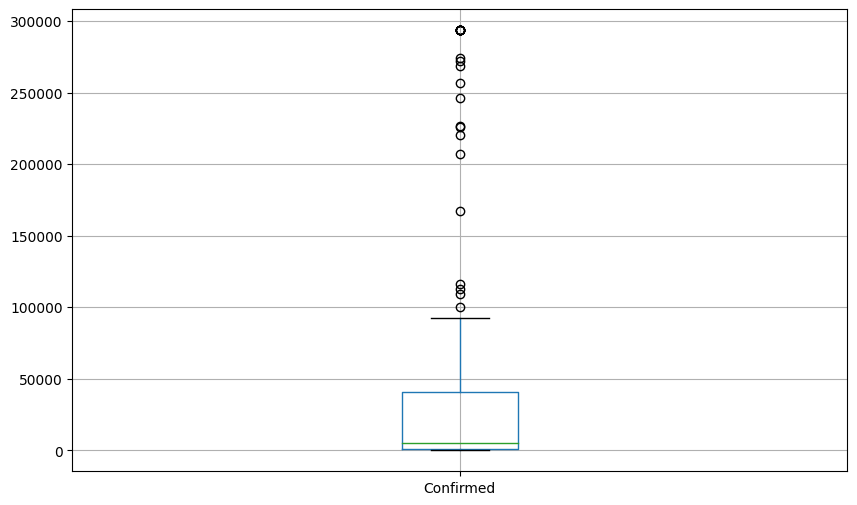

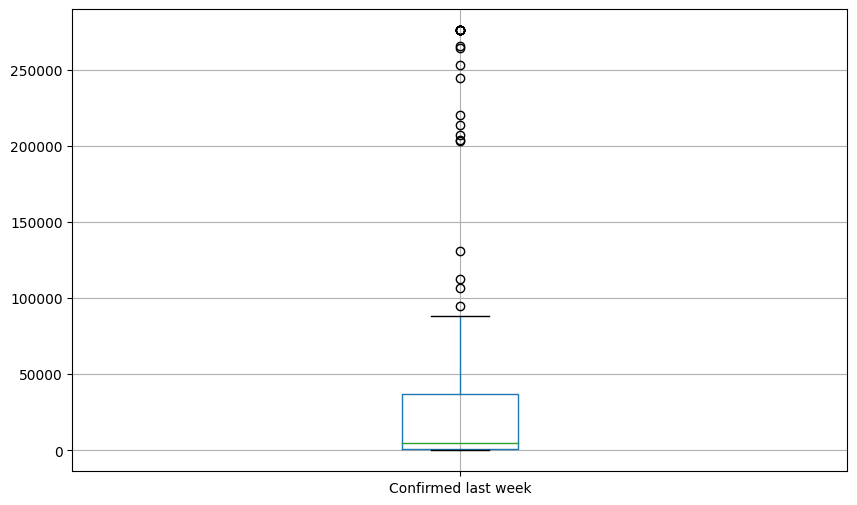

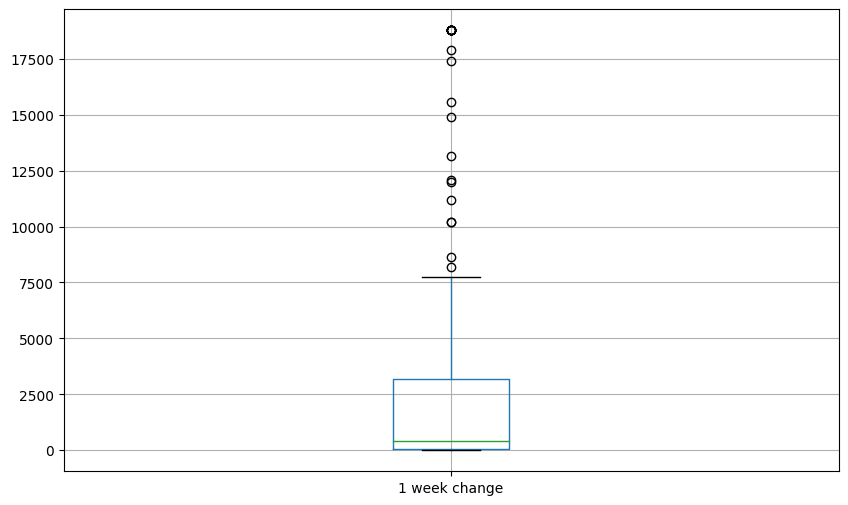

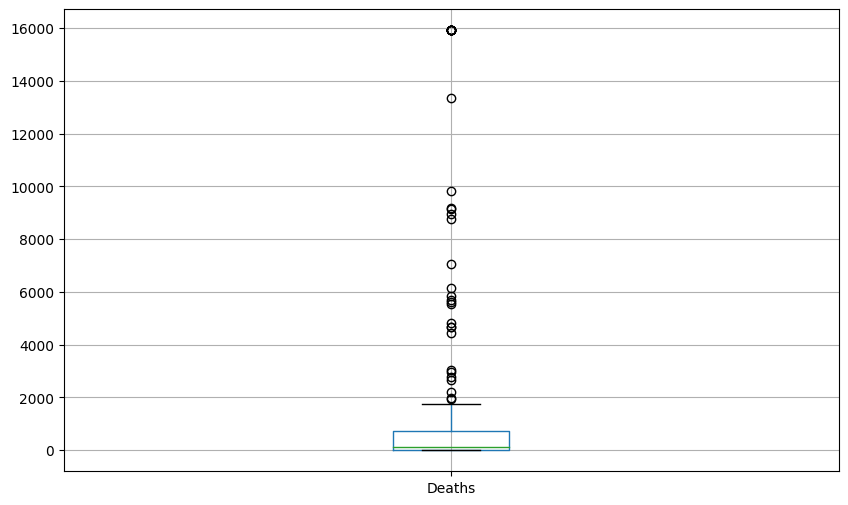

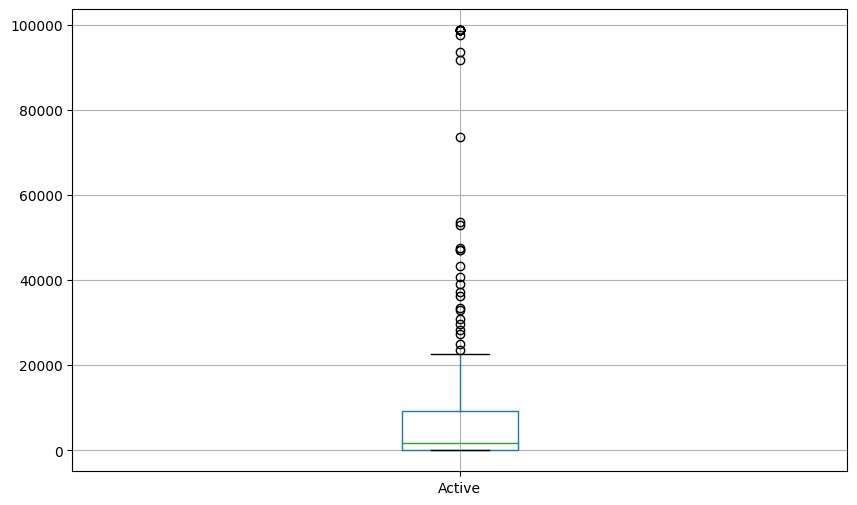

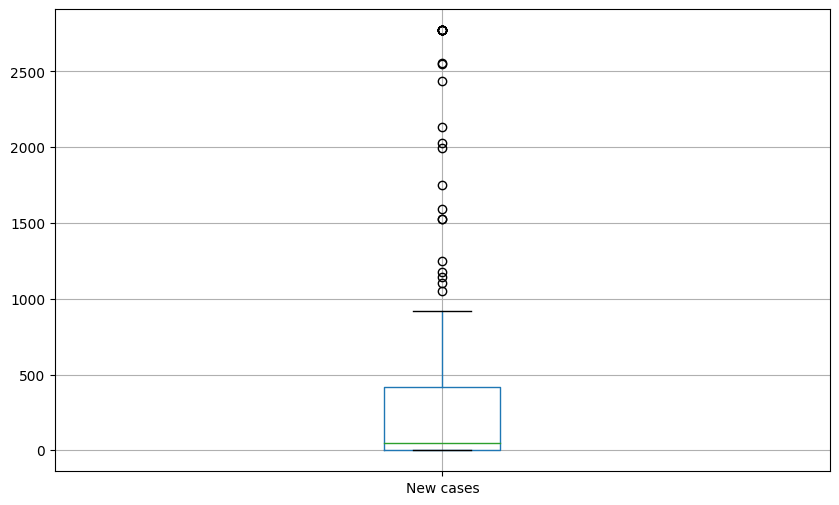

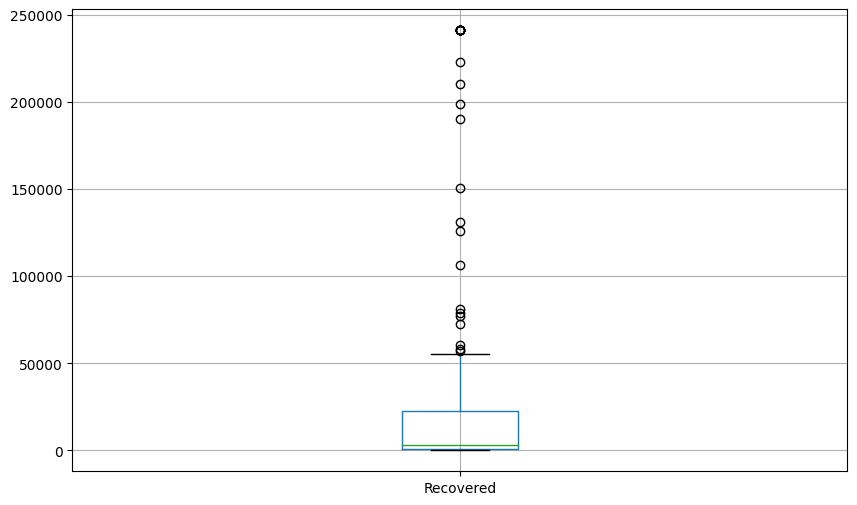

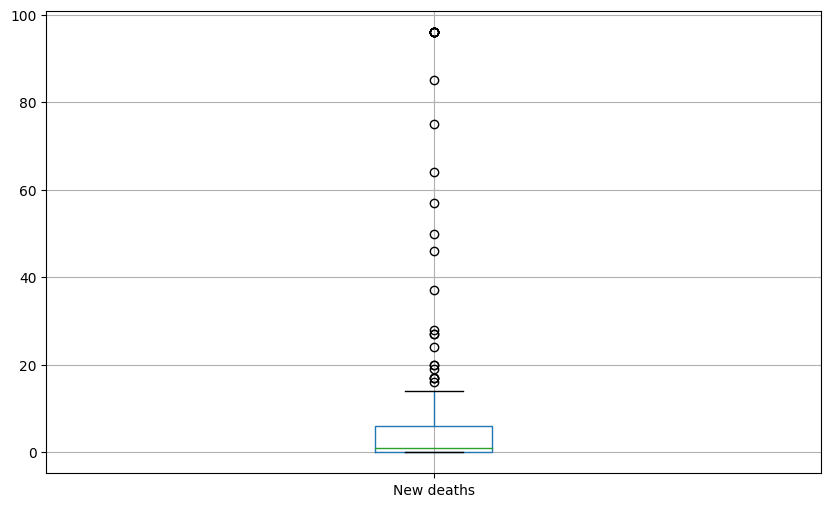

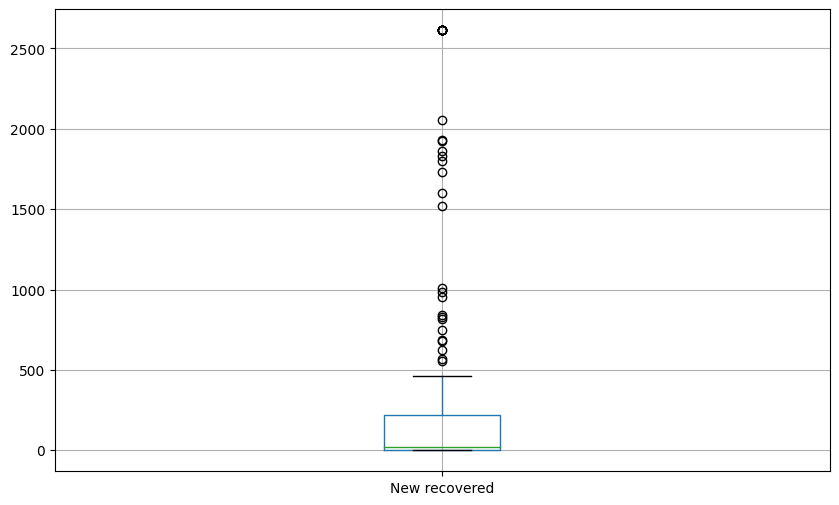

In [ ]:
numerik = ['Confirmed', 'Confirmed last week', '1 week change', 'Deaths', 'Active', 'New cases', 'Recovered',
  'New deaths', 'New recovered']

for i in copid[numerik]:
  plt.figure(figsize=(10,6))
  copid.boxplot(column=[i])

# Cluster With K-Means

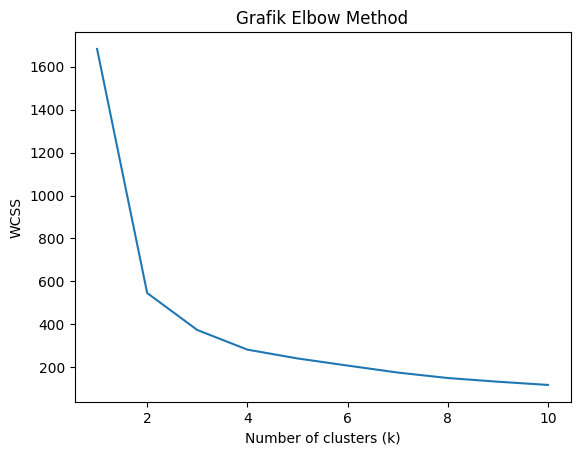

In [ ]:
numerical_columns = ['Confirmed', 'Confirmed last week', '1 week change', 'Deaths', 'Active', 'New cases', 'Recovered', 'New deaths', 'New recovered']
amazon_numerical = copid[numerical_columns]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(amazon_numerical)

wcss_list = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 11), wcss_list)
mtp.title('Grafik Elbow Method')
mtp.xlabel('Number of clusters (k)')
mtp.ylabel('WCSS')
mtp.show()

# Some Visualization about the data (EDA)

In [ ]:
# Inisialisasi LabelEncoder
le = LabelEncoder()

# Ubah kolom 'Country/Region' menjadi numerik
copid['Country/Region'] = le.fit_transform(copid['Country/Region'])

# Ubah kolom 'WHO Region' menjadi numerik
copid['WHO Region'] = le.fit_transform(copid['WHO Region'])

In [ ]:
copid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    int64  
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    in

<Axes: xlabel='New cases', ylabel='Density'>

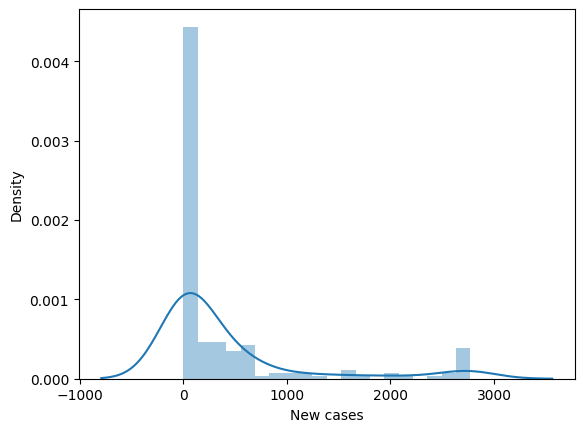

In [ ]:
sns.distplot(copid['New cases'])

<Axes: xlabel='New deaths', ylabel='Density'>

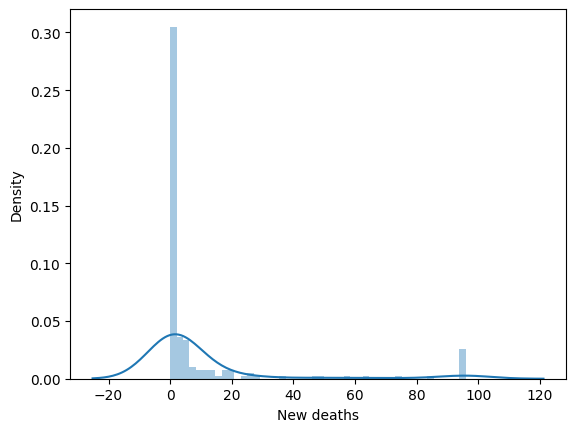

In [ ]:
sns.distplot(copid['New deaths'])

<Axes: xlabel='Deaths', ylabel='Density'>

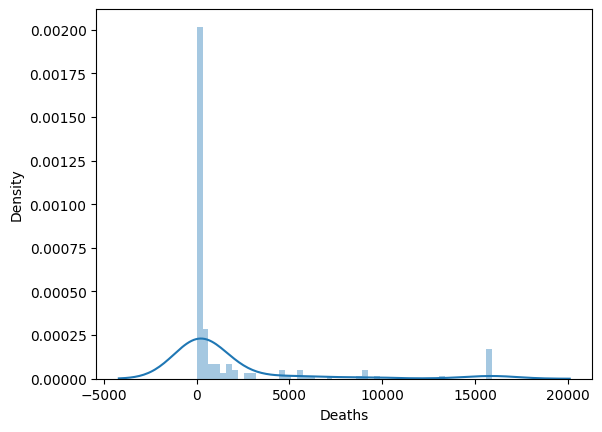

In [ ]:
sns.distplot(copid['Deaths'])

<Axes: xlabel='New recovered', ylabel='Density'>

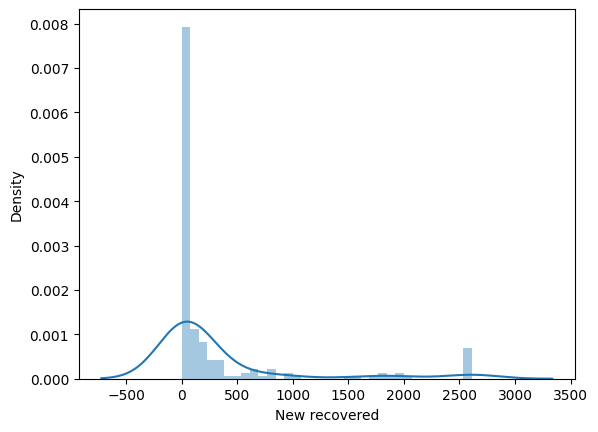

In [ ]:
sns.distplot(copid['New recovered'])